In [4]:
import kaggle

dataset_path = 'r3trovision/soil-moisture-temp-and-nutritions'
kaggle.api.dataset_download_files(dataset_path,path="DATASET/", unzip=True,quiet=False)

100%|██████████████████████████████████████████████████████████████████████████████| 7.65M/7.65M [00:40<00:00, 199kB/s]

In [1]:
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import numpy as np

In [2]:
data = pd.read_csv("../DATASET/Plant_Parameters.csv")
print(data.dtypes)

pH             float64
Soil EC        float64
Phosphorus     float64
Potassium      float64
Urea           float64
T.S.P          float64
M.O.P          float64
Moisture       float64
Temperature    float64
Plant Type      object
dtype: object


In [3]:
target = data['Moisture']  # Or specific target variable as needed
features = data.drop('Moisture',axis = 1)

In [4]:
le = LabelEncoder()
features['Plant Type'] = le.fit_transform(np.ravel(features['Plant Type']))

In [5]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2)

In [6]:
model = GradientBoostingRegressor(n_estimators=100, learning_rate =1)
model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=1)

Mean Squared Error: 11.465780566211341
R-squared: 0.8126482856419688


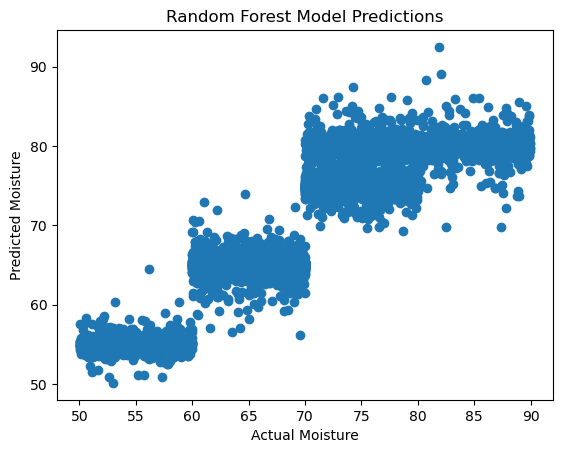

In [7]:
predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

# Optionally plot predictions vs. actual values
plt.figure()
plt.scatter(y_test, predictions)
plt.xlabel("Actual Moisture")
plt.ylabel("Predicted Moisture")
plt.title("Random Forest Model Predictions")
plt.show()

pH: 0.0050
Soil EC: 0.0442
Phosphorus: 0.0024
Potassium: 0.0014
Urea: 0.0018
T.S.P: 0.0022
M.O.P: 0.0033
Temperature: 0.0014
Plant Type: 0.9383


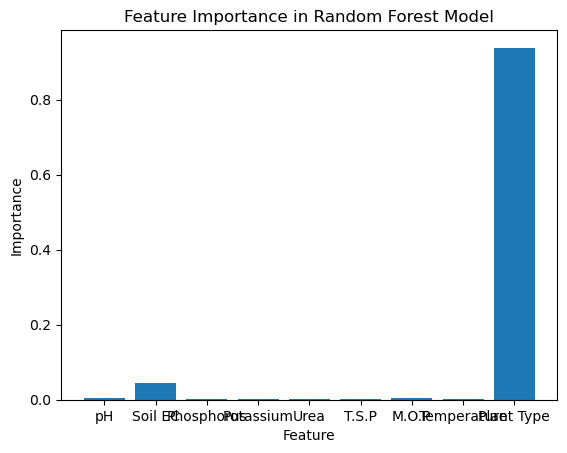

In [8]:
importances = model.feature_importances_
feature_names = features.columns

for i, name in enumerate(feature_names):
    print(f"{name}: {importances[i]:.4f}")

# Optionally plot feature importances
plt.figure()
plt.bar(feature_names, importances)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance in Random Forest Model")
plt.show()


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of boosting stages
    'learning_rate': [0.01, 0.1, 1],   # Learning rate
    'max_depth': [3, 4, 5]             # Maximum depth of the individual regression estimators
}

# Initialize the GradientBoostingRegressor
base_model = GradientBoostingRegressor()

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=base_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')

# Perform the grid search
grid_search.fit(X_train, y_train)

# Get the best parameters and best estimator
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

# Train the best model on the entire training data
best_model.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

predictions = best_model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

# Optionally plot predictions vs. actual values
plt.figure()
plt.scatter(y_test, predictions)
plt.xlabel("Actual Moisture")
plt.ylabel("Predicted Moisture")
plt.title("Gradient Boosting Model Predictions")
plt.show()

# Get feature importances
importances = best_model.feature_importances_
feature_names = list(X.columns)

for i, name in enumerate(feature_names):
    print(f"{name}: {importances[i]:.4f}")

# Optionally plot feature importances
plt.figure()
plt.bar(feature_names, importances)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance in Gradient Boosting Model")
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.show()
